# Tutorial for Lab Workflows

This section is intendend as an example of workflows for different data output formats, as a reference to customize to your own needs.
It includes outputs of three common instruments in the lab: (i) the Zeis Axiovision brightfield microscope, (ii) the Keyence BZ9000 fluorescence microscope and (iii) the Incucyte live-cell imaging system.

For additional background information and more advanced/custom analysis see the respective tutorial sections in this folder explaining the structure of the elements of the package in more detail.

If `SpheroidPy` is not installed on your system yet, we have to import its folder to the Python module search path. This is assumed as a prerequisite for the following parts.

In [4]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../../SpheroidPy')

## __Zeis Microscope:__ Custom workflow for Brightfield images

In this scenario we have several technical replicates for several different conditions, that have been imaged at consistent timepoints. The overall goal is to assign each condition a `SpheroidCollection` containing all the wells (technical replicates) within the condition as a `SpheroidSeries` containing the microscope image as a `SpheroidImage`. This is an easy way to automate data input and explains the structure behind the following iterations.

We start by importing the needed classes for the following section:

In [3]:
from SpheroidPy.spheroid import SpheroidImage, SpheroidSeries, SpheroidCollection
from datetime import datetime

For each condition, we now need to create an iteration over the wells within the conditions and create a `SpheroidSeries` for each well. We can then iterate over the different timepoints and load the images into the `SpheroidSeries`. Finally, we create a `SpheroidCollection` containing all the previously created elements. This will be the element we will use in the following for all further post-processing and analysis.

In [6]:
condition, plate = 'SCR', 1 # modify: condition name (and plate if necessary)

spheroidseries_list = []
for well in [1,6,15,16,25,30]: # modify: chosen wells
    spheroid_series = SpheroidSeries(name=f'SCR - Well {well}') # you can choose your own name :)
    
    for day in [0,3,6,10,12]: # modify: timpoints you have imaged (or how you called them in your folder structure!)
        
        # modify: use your own path (CAVE: date format)
        path = f'/Volumes/USB 32GB/new_data/Spheroide Bsp/Berdan/HROP75/Tag {day}/Platte {plate}/{condition}/{17+day}1025_HROP75_{condition}_Well{well}_BD.zvi'
        spheroid_image = SpheroidImage(brightfield=path, image_size=(1292,968))
        # Note: Each SpheroidImage needs to be assigned to a specific timepoint in order to keep track of the timesteps.
        # This however can be chosen arbitrarily. In this case we start (similar to the measurement) at 17/10/2025 at 00:00
        date_time = datetime.strptime(f'2025y10m{17+day}d_00h00m', '%Yy%mm%dd_%Hh%Mm')
        
        spheroid_series.add_spheroid_image(spheroid_image, date_time)

    spheroidseries_list.append(spheroid_series)

spheroid_collection_scr = SpheroidCollection(name='SCR', spheroid_list=spheroidseries_list) # you can choose your own name again :)

Now we can display the loaded images using the `.show()` command. Here, you can check if there have been any issues importing the images. You can also use this for segmentation (getting the contour of the spheroid). However, it is easier to do it in a automated way in the following step.

In [11]:
spheroid_collection_scr.show()

Info about segmentation :)

In [19]:
spheroid_collection_scr.segmentation(methods=('ai', 'brightfield'), threshold=0.8)

Processing segmentation: 100%|██████████| 6/6 [00:30<00:00,  5.04s/it]

Error processing SCR - Well 1 at 2025-10-17 18:00:00: All specified segmentation methods failed.
Error processing SCR - Well 6 at 2025-10-17 18:00:00: All specified segmentation methods failed.

Segmentation complete for collection 'SCR':
Successfully segmented 27/27 images across 6 series


You can now check again if everything worked using the `.show()` command as previously. 


The following steps shows how to calculate and export simple metrics based on the previously gained contour information.

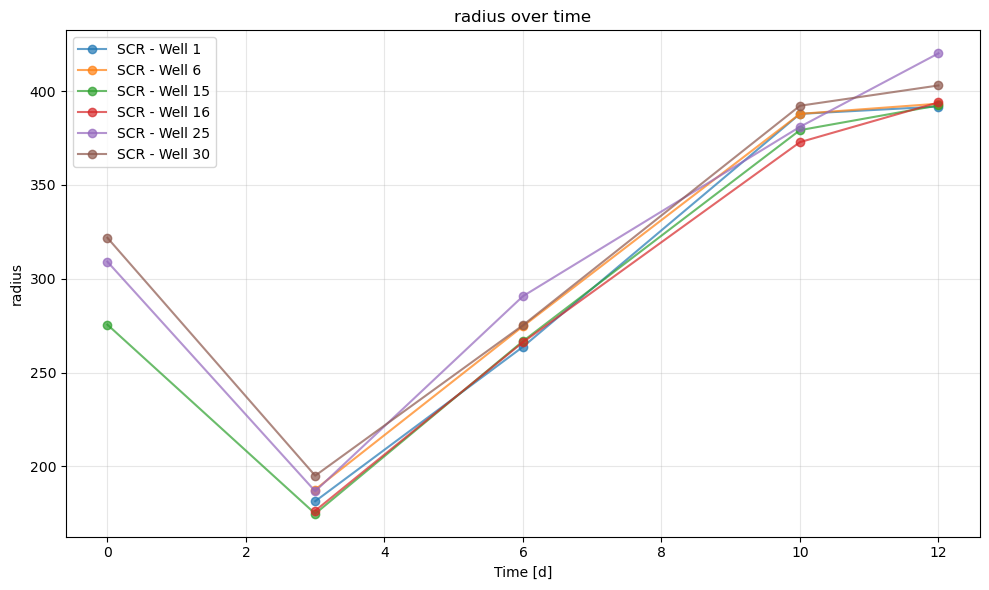

,SCR - Well 1,SCR - Well 6,SCR - Well 15,SCR - Well 16,SCR - Well 25,SCR - Well 30
0.0,NaN,NaN,275.540628,NaN,309.078585,321.822561
72.0,181.463052,187.702237,174.823226,176.416859,186.800436,195.076248
144.0,263.753954,274.701237,266.756389,266.195563,290.729307,275.273932
240.0,387.886186,387.886186,379.206337,372.810867,380.970661,392.215046
288.0,391.776147,393.322695,392.399838,393.985750,420.131493,403.020567


In [28]:
spheroid_collection_scr.calculate_metric('radius', plot=True, mean=False, interpolate=False)

We can now export the resulting dataframe directly to excel using the `.to_excel()` command:

In [30]:
spheroid_collection_scr.calculate_metric('radius', plot=False, mean=False, interpolate=False).to_excel('scr_data.xlsx')

Note: results are not being saved -> export metrics for further usage

## __Keyence:__ Custom workflow for multiple fluorescence channels
`Todo`: Yet to be written 

## __Incucyte:__ Working with large live-cell imaging datasets
We start by importing the class

We can test the images to see if everything worked and the Spheroid has been created successfully

In [6]:
from SpheroidPy.experiment import Experiment, Result   # import classes
from pathlib import Path                               # for path management

path = '/Volumes/USB 32GB/Hep3B_Spheroids'
hep3b_experiment = Experiment(name='Hep3B-Proliferation', layout=96, path=Path(path))

In [8]:
replicate1 = hep3b_experiment.result('Replicate1')

Output()

/opt/anaconda3/envs/lab/lib/python3.10/site-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/opt/anaconda3/envs/lab/lib/python3.10/site-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


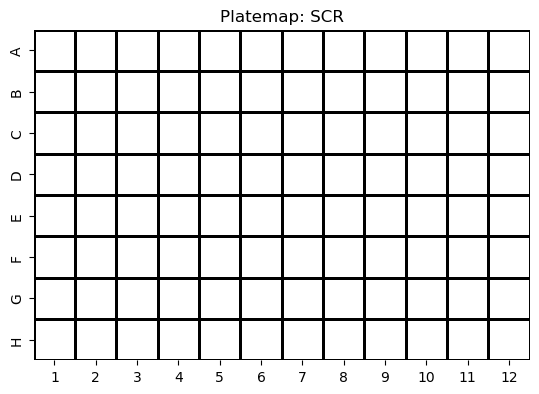

In [10]:
replicate1.platemap.cell_line('SCR')
# or to directly define multiple concentrations across specific well ranges:
# my_result.platemap.cell_line('SCR', 
#                             {4000: 'B3:G3', 800: 'B4:G4', 160: 'B5:G5'})

In [12]:
replicate1.load_images(path,
                      brightfield_filters=['Phase','contrast'], # array of str that label files of each channel
                      fluorescence_red_filters=['Red'], 
                      image_size=(1700,1270)) # image size (µm) in x- and y-direction

Looking for Wells: ['D2']


Loading wells: 100%|██████████| 1/1 [00:06<00:00,  6.60s/it]

Images have been loaded successfully!


In [13]:
hep3b_experiment.visualisation.interactive()

In [ ]:
replicate1.segmentation([('ai', 'brightfield')], confidence=0.8, reconstruct_border=True, border_margin=20)

In [74]:
replicate1.segmentation?

Signature:
replicate1.segmentation(
    methods: 'str | tuple | list' = ('thresholding', 'fluorescence_green'),
    reconstruct_border: 'bool' = True,
    **kwargs,
) -> 'None'
Docstring:
Perform spheroid segmentation across all images using multiprocessing.

Supports single or multiple segmentation attempts with different methods.
Will try methods in order until successful for each image.

Args:
    methods: Segmentation specification in one of these formats:
        - str: Channel to use with default thresholding (e.g. 'fluorescence_green')
        - tuple: (method, channel) e.g. ('ai', 'brightfield')
        - list: List of (method, channel) tuples to try in order
    reconstruct_border: Whether to reconstruct spheroid border when it
        extends beyond image bounds
    **kwargs: Method-specific parameters:
        For thresholding:
            threshold: Intensity threshold multiplier (default: 1.35)
            use_yen: Whether to use Yen's method (default: True)
            bo

In [ ]:
my_result.metric('radius', plot=True, mean=True)

If it is desired to restrict the investigation to certain time peroids during the experiment, this can be done using the `TimePeroid` class which manages ... and is embedded into the `SpheroidSeries` class via the following method